In [1]:
# IRL AutoRegressive 7
# This is an attempt to improve AutoReg 5 by computing the Log-Likelihood for every single point on trajectories and summing 
# them proportionally to the distance each 'non-optimal' point has to the 'optimal' point.

In [2]:
import crocoddyl
import pinocchio
from IPython.display import HTML
import mim_solvers
import numpy as np
import random
from matplotlib import animation
from matplotlib import pyplot as plt
from PointMass_utils import *
from PointMass_model import *
from scipy.optimize import minimize
from scipy.optimize import Bounds

In [3]:
nx = 4
nu = 2
T = 50
# start_point = np.array([0, 0, 0, 0])
start_point = np.array([2, 5, 0, 0])
target_low = np.array([10, 0, 0, 0])
# target_high = np.array([10, 10, 0, 0])
target_high = np.array([8, 5, 0, 0])
obs_act = 2.5
obs0 = Obstacle(10, 8, 2, obs_act, 'Obs0')
# obs1 = Obstacle(8, 8, 1, obs_act, 'Obs1')
# obs2 = Obstacle(8, 10, 1, obs_act, 'Obs2')
# obs3 = Obstacle(10, 8, 1, obs_act, 'Obs3')
# obs4 = Obstacle(10, 12, 1, obs_act, 'Obs4')
# obs5 = Obstacle(8, 12, 1, obs_act, 'Obs5')
obs1 = Obstacle(7, 3, 1, obs_act, 'Obs1')
obs2 = Obstacle(6, 4, 1, obs_act, 'Obs2')
obs3 = Obstacle(5, 5, 1, obs_act, 'Obs3')
obs4 = Obstacle(6, 6, 1, obs_act, 'Obs4')
obs5 = Obstacle(7, 7, 1, obs_act, 'Obs5')
obs6 = Obstacle(3, 5, 1, obs_act, 'Obs6')
obs7 = Obstacle(5, 2, 1, obs_act, 'Obs7')
obs8 = Obstacle(2.5, 2, 1, obs_act, 'Obs8')
obs_set = [obs1, obs2, obs3, obs4, obs5]#, obs6, obs7, obs8]
# obs_set = [obs0]
translation_cost = XReg(nx, target_high, 'trans_high')
xreg = XReg(nx, start_point, 'XReg')
ureg = UReg(nu, None, 'UReg')

cost_set = Costs()
cost_set.add_cost(translation_cost)
cost_set.add_cost(xreg)
cost_set.add_cost(ureg)
# cost_set.add_cost(obs0)
cost_set.add_cost(obs1)
cost_set.add_cost(obs2)
cost_set.add_cost(obs3)
cost_set.add_cost(obs4)
cost_set.add_cost(obs5)
# cost_set.add_cost(obs6)
# cost_set.add_cost(obs7)
# cost_set.add_cost(obs8)

nr = cost_set.nr

In [4]:
# Desired Weights
w_run_possibles = np.array([10, 1., 1., 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000])
w_term_possibles = np.array([2000, 1., 1., 10, 10, 10, 10, 10, 10, 10, 10])
w_run = w_run_possibles[:nr]
w_term = w_term_possibles[:nr]
obs_set = obs_set[:nr]
# w_des = np.hstack([w_run, w_term])
w_des = (np.hstack([w_run, w_term])/(np.max(np.hstack([w_run, w_term])))).copy()
# w_des = (np.hstack([w_run, w_term])/(np.linalg.norm(np.hstack([w_run, w_term])))).copy()

In [5]:
samples = 10
xlims = [0, 10]
ylims = [0, 10]
x0 = start_point; u0 = np.array([0.0, 0.0])
xs_init = [x0 for i in range(T+1)]; us_init = [u0 for i in range(T)]
timeStep = 5e-2
max_iter = 500
# XS_Set_optimal, US_Set_optimal = test_model_full(cost_set, obs_set, samples, xlims, ylims, T, w_des, timeStep, max_iter, with_callback = False)
# xs_optimal = XS_Set_optimal[0]
# us_optimal = US_Set_optimal[0]
xs_optimal, us_optimal, _ = get_results_from_model(cost_set, xs_init, us_init, T, w_des, timeStep, max_iter, with_callback = True)

iter     merit         cost         grad      step    ||gaps||        KKT
   1  1.85381e+01  1.85381e+01  7.08244e+00  1.0000  0.00000e+00  3.72087e+00
   2  8.19651e+00  8.19651e+00  1.31521e-02  1.0000  1.77636e-14  2.50705e-02
   3  8.19043e+00  8.19043e+00  1.28503e-02  1.0000  3.86827e-11  2.54154e-02
   4  8.18458e+00  8.18458e+00  1.25807e-02  1.0000  3.04781e-11  2.57382e-02
   5  8.17894e+00  8.17894e+00  1.23368e-02  1.0000  3.35553e-11  2.60404e-02
   6  8.17349e+00  8.17349e+00  1.21163e-02  1.0000  2.99021e-11  2.63233e-02
   7  8.16820e+00  8.16820e+00  1.19181e-02  1.0000  3.66040e-11  2.65884e-02
   8  8.16305e+00  8.16305e+00  1.17390e-02  1.0000  3.25838e-11  2.68367e-02
   9  8.15802e+00  8.15802e+00  1.15813e-02  1.0000  3.22750e-11  2.70693e-02
  10  8.15310e+00  8.15310e+00  2.96110e-01  1.0000  3.84197e-11  2.71073e-01
iter     merit         cost         grad      step    ||gaps||        KKT
  11  8.07762e+00  8.07762e+00  2.31909e-01  1.0000  2.67007e-10  1.1823

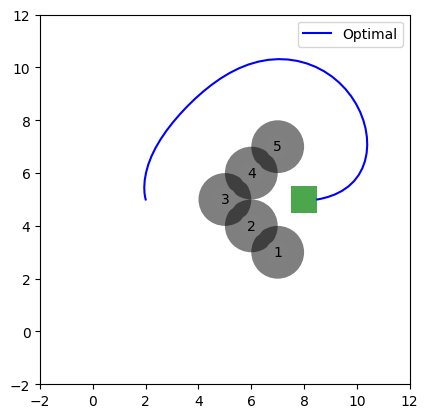

In [6]:
# HTML(animatePointMass(xs_optimal, obs_set, target_high).to_jshtml())
plot_1_traj(np.vstack(xs_optimal), obs_set, target_high, label='Optimal', linemap = 'b')

In [7]:
# Bad Running and Terminal Model
w_bad = np.zeros_like(w_des)
w_run = w_bad[:nr]
w_term = w_bad[nr:]

xs_non_optimal, us_non_optimal, sqp_non_opt = get_results_from_model(cost_set, xs_init, us_init, T, w_bad, timeStep, max_iter, with_callback = False)

In [8]:
# HTML(animatePointMass(xs_non_optimal, obs_set, target_high).to_jshtml())
# plot_1_traj(np.vstack(xs_non_optimal), obs_set, target_high, label='Non-Optimal', linemap = 'r')

In [9]:
# IRL Algorithm
def pick_highs(opt_vals, num):
    vals = np.stack(opt_vals)
    inds = sorted(range(len(vals)), key=lambda i: vals[i])[-num:][::-1]
    return inds

def pick_lows(opt_vals, num):
    vals = np.stack(opt_vals)
    inds = sorted(range(len(vals)), key=lambda i: vals[i])[:num][::-1]
    return inds

def get_cov(X):
    m = get_mean(X)
    s = np.zeros(shape=(m.shape[0],m.shape[0]))
    for x in X:
        s += (x[:,None]-m[:,None])@(x[:,None]-m[:,None]).T
    s /= len(X)
    # s += np.identity(m.shape[0])*1e-15 # Regularization
    return s

def get_mean(X):
    m = np.zeros(shape=X[0].shape)
    for x in X:
        m += x
    m /= len(X)
    return np.squeeze(m)

def get_mean_cov(phis, scale = 0.0, reg = 1e-15):
    # The new feature space will attain a covariance with 
    # our determined eigenvalues, if the features are pre-multiplied by 'cov_inv_sqrt'.
    # If scale = 0.0, the eigenvalues are all 1, if scale = 1.0, the eigenvalues won't change.
    
    new_phis = []
    phis = np.stack(phis)
    mean = get_mean(phis)
    reg_mat = np.diag(np.ones_like(mean)) * reg
    cov = get_cov(phis) + reg_mat
    if len(phis) <= len(phis[0]):
        cov_inv_sqrt = np.identity(len(phis[0]))
    else:
        EVal, EVec = np.linalg.eig(cov)
        EV_new = np.ones_like(EVal)**scale
        C_p = EVec@(np.diag(np.sqrt(EVal/EV_new)))@EVec.T
        cov_inv_sqrt = np.linalg.inv(C_p)
    return mean, cov, cov_inv_sqrt

def get_phi_set(cost_set, xs, us, dt):
    phis = []
    for i, (X, U) in enumerate(zip(xs, us)):
        phis.append(cost_set.cum_feat(X, U, dt))
    return phis

def likelihood(cost_set, x_opt, u_opt, xs_set, us_set, w_run, w_term, dt, set_params):
    use_norm = set_params['use_norm']
    L = len(x_opt)-1
    attempts = 20
    ll = 0.0
    cost_stack = []
    cost_opt, _, costs_opt = cost_set.traj_cost_and_feat_multiple(x_opt, u_opt, w_run, w_term, dt, attempts)
    for x_, u_ in zip(xs_set, us_set):
        cost_nopt, _, costs_nopt = cost_set.traj_cost_and_feat_multiple(x_, u_, w_run, w_term, dt, attempts)
        cost_stack.append(costs_nopt)

    for i in range(attempts):
        num = 1.0
        den = 1.0
        c_o = costs_opt[i]
        for c_no in cost_stack:
            den += np.max([np.nextafter(0,1),(np.exp(-(c_no[i] - c_o)))])
        ll += np.log(num/den)
    
    return ll
            
def KL_D(cost_set, xs, us, w_old, w_new, dt, set_params):
    nr = cost_set.nr
    kl_array = np.zeros(len(xs))
    Px = np.zeros(len(xs))
    Qx = np.zeros(len(us))
    kl_div = 0.0
    for i, (X, U) in enumerate(zip(xs,us)):
        xs_temp = xs.copy(); xs_temp.pop(i)
        us_temp = us.copy(); us_temp.pop(i)
        Px[i] = likelihood(cost_set, X, U, xs_temp, us_temp, w_old[:nr], w_old[nr:], dt, set_params)
        Qx[i] = likelihood(cost_set, X, U, xs_temp, us_temp, w_new[:nr], w_new[nr:], dt, set_params)
    Px = Px/np.sum(Px)
    Qx = Qx/np.sum(Qx)
    kl_array = Px*np.log(Px/Qx)
    kl_div = np.sum(kl_array)
    return kl_div, kl_array


def fcn_w(x, cost_set, xs_optimal, us_optimal, xs_non_optimal_set, us_non_optimal_set, dt, set_params, Lambda = 0.001):
    nr = cost_set.nr
    output = 0
    x_run = x[:nr]; x_term = x[nr:]
    ll = likelihood(cost_set, xs_optimal, us_optimal, xs_non_optimal_set, us_non_optimal_set, x_run, x_term, dt, set_params)
    output -= ll
    output += Lambda*np.linalg.norm(x)
    return output


In [10]:
# IRL Params
dt = timeStep
Lambda = 0.0
lb = 0; ub = np.inf
bnds = Bounds(lb, ub)
options = {'maxiter': 1, 'iprint': -1,'ftol': 1e-10 ,'gtol' : 1e-10}
tol = 1e-10
pick_best = True
pick_worst = False
stochastic = False
init_choices = ['bad','optimal','previous', 'best']


w0 = w_bad
w_loop = w0
w_prev = w0
it = 0
max_set_size = 10
# it_max_IRL = max_set_size + 1
it_max_IRL = 50
it_min_IRL = nr; it_min = True
it_max_sqp = 1

xs = []
us = []
xs_all = []
us_all = []
xs_non_optimal_set = []
us_non_optimal_set = []
ws = []
Fcns= []
Phis = []
KL_div = [10]; KL = 10
KL_arrs = []; KL_arrs.append(np.zeros(10))
Cost_Diffs = [1.0]
W_Diffs = [1.0]
Traj_Diffs = [1.0]
Opt_Vals = [1.0]
mean = np.zeros(cost_set.nr)
cov_inv_sqrt = np.identity(cost_set.nr)

xs_all.append(np.vstack(xs_optimal).copy()); xs_all.append(np.vstack(xs_non_optimal).copy())
us_all.append(np.vstack(us_optimal).copy()); us_all.append(np.vstack(us_non_optimal).copy())
xs_non_optimal_set.append(np.vstack(xs_non_optimal).copy()); xs.append(np.vstack(xs_non_optimal).copy())
us_non_optimal_set.append(np.vstack(us_non_optimal).copy()); us.append(np.vstack(us_non_optimal).copy())

ws.append(w_bad)

best_x = xs_non_optimal
best_u = us_non_optimal


damping = 5
loop_tol = 1e-10
opt_feat= cost_set.cum_feat(xs_optimal,us_optimal,dt);
non_opt_feat= cost_set.cum_feat(xs_non_optimal, us_non_optimal, dt);
optimality = (np.linalg.norm(opt_feat - non_opt_feat))/(np.linalg.norm(opt_feat - non_opt_feat))
prev_optimality = optimality
prev_kld = 11; KL = 10
prev_eig_norm = 1; eig_norm = 2
prev_det = 1; det = 2

# Dataset Params
set_params = {
    'use_norm': False,
    'mean': mean,
    'zero_mean': np.zeros_like(mean),
    'cov': None,
    'cov_inv_sqrt': cov_inv_sqrt,
    'phi_opt': opt_feat,
    'All_phis': [opt_feat, non_opt_feat],
    'Curr_set_x': [xs_optimal, xs_non_optimal],
    'Curr_set_u': [us_optimal, us_non_optimal],
    'Curr_set_phis': [opt_feat, non_opt_feat],
    'Set_phis': [non_opt_feat],
    'Set_eigs': [],
    'Set_dets': [],
    'Best_eigs': [],
    'Best_dets': [],
    't': 0
}

prev_phi_inds = []
phi_inds = [0]
print('Optimal Trajectory Cost with Desired Weights: ', cost_set.traj_cost(xs_optimal, us_optimal, w_des[:nr], w_des[nr:], dt))

# while ((prev_eig_norm-eig_norm) != 0.0 and KL > loop_tol and it < it_max_IRL) or (it_min):
# while (prev_phi_inds != phi_inds and KL > loop_tol and it < it_max_IRL) or (it_min):
while (KL > loop_tol and it < it_max_IRL) or (it_min):
    prev_det = det; prev_eig_norm = eig_norm; prev_phi_inds = phi_inds
    
    if len(set_params['Curr_set_phis']) > nr+2:
        set_params['use_norm'] = False
        # set_params['mean'], set_params['cov'], set_params['cov_inv_sqrt'] = get_mean_cov(set_params['Curr_set_phis'], scale = 0.0, reg = 1e-15)
    else:
        set_params['use_norm'] = False
        # set_params['mean'], set_params['cov'], set_params['cov_inv_sqrt'] = get_mean_cov(set_params['All_phis'], scale = 0.0, reg = 1e-15)
    # set_params['Set_eigs'].append(np.linalg.eig(set_params['cov'])[0])
    # set_params['Set_dets'].append(np.linalg.det(set_params['cov']))
    # det = np.linalg.det(get_cov(set_params['Curr_set_phis']))
    # set_params['Best_dets'].append(det)
    # eig_norm = np.linalg.norm(np.linalg.eig(get_cov(set_params['Curr_set_phis']))[0])
    # set_params['Best_eigs'].append(np.linalg.eig(get_cov(set_params['Curr_set_phis']))[0])
        
    # for t in range(T, 0, -2):
    # set_params['t'] = t
    res = minimize(fcn_w, 
                   w_loop, 
                   args=(cost_set, xs_optimal, us_optimal, xs_non_optimal_set, us_non_optimal_set, dt, set_params, Lambda), 
                   bounds=bnds, 
                   method='L-BFGS-B', 
                   tol = tol,
                   options=options)
    # w_loop = res.x.copy()

    # w_loop = w0
    w_curr = res.x.copy()
    dw = normalize(np.squeeze(w_curr)) - w_prev
    w_loop = w_prev + (dw/damping) 
    w_loop = normalize(w_loop)
    w_run = w_loop[:nr]; w_term = w_loop[nr:]
    fcn_value = fcn_w(w_loop, cost_set, xs_optimal, us_optimal, xs, us, dt, set_params, Lambda); Fcns.append(fcn_value)
    
    # initial = random.choice(init_choices)
    initial = 'optimal'
    if initial == 'previous':
        # Warm-Start with previous trajectory
        xs_init = [sqp_non_opt.xs.copy()[i] for i in range(T+1)]
        us_init = [sqp_non_opt.us.copy()[i] for i in range(T)]
    elif initial == 'optimal':
        # Warm-Start with optimal trajectory
        xs_init = [xs_optimal[i] for i in range(T+1)]
        us_init = [us_optimal[i] for i in range(T)]
    elif initial == 'bad':
        # Warm-Start with zero trajectory
        xs_init = [x0 for i in range(T+1)]
        us_init = [u0 for i in range(T)]
    elif initial == 'best':
        xs_init = [best_x[i] for i in range(T+1)]
        us_init = [best_u[i] for i in range(T)]
    

    sqp_non_opt = reset_weights(sqp_non_opt, w_loop[:nr], w_loop[nr:])
    done = sqp_non_opt.solve(xs_init, us_init, it_max_sqp)
    new_traj_x = sqp_non_opt.xs.tolist().copy()
    new_traj_u = sqp_non_opt.us.tolist().copy()
    
    # Add the trajectory to the set
    xs.append(np.vstack(new_traj_x)); xs_all.append(np.vstack(new_traj_x))
    us.append(np.vstack(new_traj_u)); us_all.append(np.vstack(new_traj_u))
    ws.append(w_loop.copy())
    traj_feat = cost_set.cum_feat(new_traj_x, new_traj_u, dt)
    set_params['All_phis'].append(traj_feat)
    optimality = (np.linalg.norm(traj_feat - opt_feat))/(np.linalg.norm(opt_feat - non_opt_feat)); Opt_Vals.append(optimality)
    w_diff = np.linalg.norm(w_loop - w_prev); W_Diffs.append(w_diff)
    opt_traj_cost = cost_set.traj_cost(xs_optimal, us_optimal, w_loop[:nr], w_loop[nr:], dt)
    traj_diff = np.abs(sqp_non_opt.cost - opt_traj_cost); Traj_Diffs.append(traj_diff)
    
    if optimality < prev_optimality:
        best_x = sqp_non_opt.xs.copy()
        best_u = sqp_non_opt.us.copy()

    set_params['Curr_set_phis'] = [opt_feat]

    if len(xs) < max_set_size:
        xs_non_optimal_set = xs
        us_non_optimal_set = us
    else:
        if pick_best:
            inds = pick_lows(Opt_Vals,max_set_size)
            xs_non_optimal_set = [xs[i] for i in inds]
            us_non_optimal_set = [us[i] for i in inds]
            phi_inds = inds
        elif pick_worst:
            inds = pick_highs(Opt_Vals,max_set_size)
            xs_non_optimal_set = [xs[i] for i in inds]
            us_non_optimal_set = [us[i] for i in inds]
            phi_inds = inds
        else:
            xs_non_optimal_set = xs[-max_set_size:]
            us_non_optimal_set = us[-max_set_size:]
    
    if len(xs) < nr + 1:
        set_params['Curr_set_phis'] = set_params['All_phis']
    else:
        if pick_best:
            phi_inds = pick_lows(Opt_Vals,nr + 1)
            set_params['Set_phis'] = [set_params['All_phis'][i] for i in phi_inds]
            set_params['Curr_set_phis'] = set_merge(set_params['Curr_set_phis'], set_params['Set_phis'])
        elif pick_worst:
            phi_inds = pick_highs(Opt_Vals,nr + 1)
            set_params['Set_phis'] = [set_params['All_phis'][i] for i in phi_inds]
            set_params['Curr_set_phis'] = set_merge(set_params['Curr_set_phis'], set_params['Set_phis'])
        else:
            set_params['Set_phis'] = set_params['All_phis'][-max_set_size:]
            set_params['Curr_set_phis'] = set_merge(set_params['Curr_set_phis'], set_params['Set_phis'])
   

    if it > 0:
        set_params['use_norm'] = False
        xs_w_opt = set_merge([xs_optimal], xs_non_optimal_set); us_w_opt = set_merge([us_optimal], us_non_optimal_set)
        # KL, KL_arr = KL_D(cost_set, xs_all, us_all, w_prev, w_loop, dt); KL_div.append(KL); KL_arrs.append(KL_arr)
        # KL, KL_arr = KL_D(cost_set, xs_non_optimal_set, us_non_optimal_set, w_prev, w_loop, dt); KL_div.append(KL); KL_arrs.append(KL_arr)
        KL, KL_arr = KL_D(cost_set, xs_w_opt, us_w_opt, w_prev, w_loop, dt, set_params); KL_div.append(KL); KL_arrs.append(KL_arr)
        KL_des, _ = KL_D(cost_set, xs_w_opt, us_w_opt, w_des, w_loop, dt, set_params)
        print('Iter: {} || KLD: {:.5f} || Desired KLD: {:.5f} || Traj Diff: {:.4f}, || Opt_Div: {:.4f} || Optimal Traj Cost: {:.4f}'.format(
            it+1, KL, KL_des, traj_diff, optimality, opt_traj_cost
        ))
        
    d_opt = prev_optimality - optimality
    prev_optimality = optimality
    # Initial W for IRL as previous weights
    w_prev = w_loop.copy()
    it += 1
    if it > it_min_IRL:
        it_min = False

    

print(res)

Optimal Trajectory Cost with Desired Weights:  1.1083918608665337
Iter: 2 || KLD: 0.00041 || Desired KLD: 0.00119 || Traj Diff: 0.0000, || Opt_Div: 0.1567 || Optimal Traj Cost: 0.2933
Iter: 3 || KLD: 0.00619 || Desired KLD: 0.05170 || Traj Diff: 0.0000, || Opt_Div: 0.7652 || Optimal Traj Cost: 1.6733
Iter: 4 || KLD: 0.00070 || Desired KLD: 0.02947 || Traj Diff: 0.0000, || Opt_Div: 0.5477 || Optimal Traj Cost: 1.7611
Iter: 5 || KLD: 0.00046 || Desired KLD: 0.01787 || Traj Diff: 0.0000, || Opt_Div: 0.4718 || Optimal Traj Cost: 1.8187
Iter: 6 || KLD: 0.00030 || Desired KLD: 0.01131 || Traj Diff: 0.0000, || Opt_Div: 0.4288 || Optimal Traj Cost: 1.8334
Iter: 7 || KLD: 0.00039 || Desired KLD: 0.00690 || Traj Diff: 0.0000, || Opt_Div: 0.3845 || Optimal Traj Cost: 2.4011
Iter: 8 || KLD: 0.00126 || Desired KLD: 0.00537 || Traj Diff: 0.0000, || Opt_Div: 0.3257 || Optimal Traj Cost: 3.7396
Iter: 9 || KLD: 0.00012 || Desired KLD: 0.00400 || Traj Diff: 0.0000, || Opt_Div: 0.3069 || Optimal Traj Cos

In [11]:
KL

2.018229237390985e-06

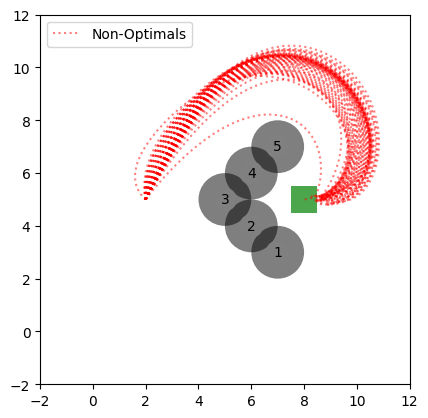

In [12]:
plot_1_set(xs, obs_set, target_high, label='Non-Optimals', linemap_traj='r:', linemap_set='r:')

processing the animation ... 
... processing done


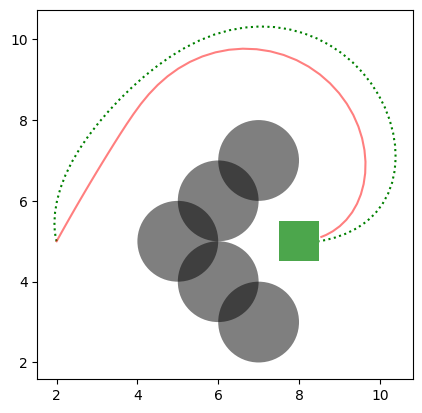

In [13]:
HTML(animateTraj(xs_optimal, xs, obs_set, target_high, max_set_size, sleep=500, animType=2).to_jshtml())

In [14]:
len(ws)

51

In [39]:
w_irl = ws[20]

In [40]:
for i, cost in enumerate(cost_set.costs):
    print(cost.name, ':')
    print('Running || ', 'Desired: ', w_des[:nr][i], 'IRL: ', w_irl[:nr][i])
    print('Terminal || ', 'Desired: ', w_des[nr:][i], 'IRL: ', w_irl[nr:][i])
    print('')

trans_high :
Running ||  Desired:  0.005 IRL:  0.0
Terminal ||  Desired:  1.0 IRL:  0.6239208826255738

XReg :
Running ||  Desired:  0.0005 IRL:  0.0
Terminal ||  Desired:  0.0005 IRL:  0.14352289187872133

UReg :
Running ||  Desired:  0.0005 IRL:  0.0009355547765535995
Terminal ||  Desired:  0.0005 IRL:  0.0

Obs1 :
Running ||  Desired:  1.0 IRL:  0.16044036034739184
Terminal ||  Desired:  0.005 IRL:  0.30872673854992344

Obs2 :
Running ||  Desired:  1.0 IRL:  0.12126146326817168
Terminal ||  Desired:  0.005 IRL:  0.31944825217551565

Obs3 :
Running ||  Desired:  1.0 IRL:  0.019918823296347508
Terminal ||  Desired:  0.005 IRL:  0.10878084684596803

Obs4 :
Running ||  Desired:  1.0 IRL:  0.22603508610260356
Terminal ||  Desired:  0.005 IRL:  0.18376681059789182

Obs5 :
Running ||  Desired:  1.0 IRL:  1.0
Terminal ||  Desired:  0.005 IRL:  0.0612939068826698



In [41]:
print('Desired:                 ', fcn_w(w_des, cost_set, xs_optimal, us_optimal, xs, us, dt, set_params, Lambda)) 
print('IRL:                     ', fcn_w(w_irl, cost_set, xs_optimal, us_optimal, xs, us, dt, set_params, Lambda))
print('')
print('Desired Trajectory Cost: ', cost_set.traj_cost(xs_optimal, us_optimal, w_des[:nr], w_des[nr:], timeStep))
print('with IRL Weight:         ', cost_set.traj_cost(xs_optimal, us_optimal, w_irl[:nr], w_irl[nr:], timeStep))
print('')
print('IRL Trajectory Cost:     ', cost_set.traj_cost(xs[-1], us[-1], w_irl[:nr], w_irl[nr:], timeStep))
print('with Desired Weight:     ', cost_set.traj_cost(xs[-1], us[-1], w_des[:nr], w_des[nr:], timeStep))

Desired:                  76.87360194488762
IRL:                      77.14966655888196

Desired Trajectory Cost:  1.1083918608665337
with IRL Weight:          4.002017352114462

IRL Trajectory Cost:      4.331765819676726
with Desired Weight:      1.6022631253972057


In [42]:
# Testing
w_run = w_irl[:nr]
w_term = w_irl[nr:]

# Zero Warm Start
x0 = start_point; u0 = np.array([0.0, 0.0])
xs_init = [x0 for i in range(T+1)]
us_init = [u0 for i in range(T)]

# # Optimal Warm Start
# xs_init = [xs_optimal[i] for i in range(T+1)]
# us_init = [us_optimal[i] for i in range(T)]

xs_output, us_output, sqp = get_results_from_model(cost_set, xs_init, us_init, T, w_irl, timeStep, max_iter, with_callback = True)

iter     merit         cost         grad      step    ||gaps||        KKT
   1  1.12504e+01  1.12504e+01  7.18477e+00  1.0000  0.00000e+00  3.62775e+00
   2  5.46190e+00  5.46190e+00  2.08717e-01  1.0000  1.19904e-14  9.83189e-02
   3  5.39196e+00  5.39196e+00  1.99276e-01  1.0000  2.46244e-10  8.99342e-02
   4  5.31977e+00  5.31977e+00  1.98995e-01  1.0000  2.48862e-10  7.50170e-02
   5  5.24682e+00  5.24682e+00  1.26485e+01  0.2500  2.73194e-10  1.15850e+00
   6  5.04465e+00  5.04465e+00  8.41392e-01  1.0000  3.67987e-09  6.90537e-01
   7  4.63441e+00  4.63441e+00  2.48677e+00  1.0000  8.51015e-10  8.96247e-02
   8  4.45661e+00  4.45661e+00  6.29337e+00  1.0000  3.96291e-09  1.25132e-01
   9  4.22560e+00  4.22560e+00  1.16408e+01  1.0000  1.20386e-08  2.21973e-01
  10  4.10558e+00  4.10558e+00  1.03513e+01  1.0000  2.10990e-08  3.42178e-02
iter     merit         cost         grad      step    ||gaps||        KKT
  11  4.04610e+00  4.04610e+00  1.70794e+01  1.0000  1.98347e-08  3.2926

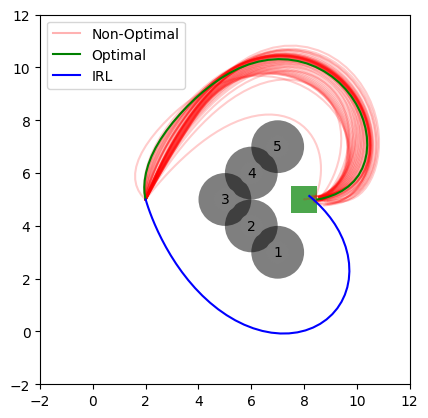

In [43]:
plot_results(xs_optimal, xs, xs_output, obs_set, target_high)

In [44]:
P_irl = distributions(cost_set, xs_all[:-2], us_all[:-2], w_irl[:nr], w_irl[nr:], dt)
P_des = distributions(cost_set, xs_all[:-2], us_all[:-2], w_des[:nr], w_des[nr:], dt)

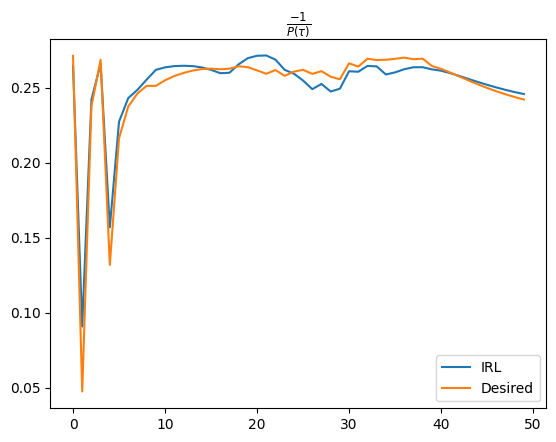

In [45]:
plt.plot(-1/np.log(P_irl),label='IRL')
plt.plot(-1/np.log(P_des),label='Desired')
plt.legend()
plt.gca().set_title(r'$\frac{-1}{P(\tau)}$')
plt.show()

In [46]:
XS_Set, US_Set = test_model_full(cost_set, obs_set, 5, xlims, ylims, T, w_irl, timeStep, max_iter, with_callback = False)

10 Trajectories Collected
Trajectory 13 Rejected
Trajectory 17 Rejected
Trajectory 19 Rejected
20 Trajectories Collected


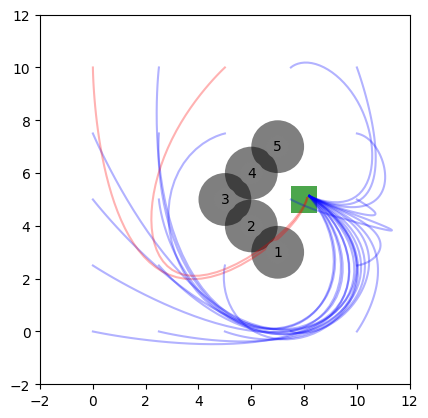

Number of Collisions: 2


In [47]:
plot_tested_model(XS_Set, obs_set, target_high)